In [25]:
# ==============================================================================
# TECHMIND v2.0
# NOTEBOOK 01
# EXPLORATORY DATA ANALYSIS (EDA)
#
# Hackathon ONE G9 | Oracle + Alura
#
# Equipo:
# Ciencia de Datos
#
# Objetivo:
# Comprender la estructura y calidad del dataset antes del modelado.
# ==============================================================================

In [26]:
!pip install wordcloud

In [27]:
!pip install nltk

In [ ]:
# CELDA 4

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from wordcloud import WordCloud

import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MAMÁ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# CELDA 5

plt.style.use("ggplot")

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

pd.set_option("display.max_colwidth", 120)

In [ ]:
# ==============================================================================
# CELDA 6
# ==============================================================================

DATASET_PATH = "dataset_tecnico_hackathon_prueba_4.csv"

df = pd.read_csv(DATASET_PATH)

print(df.shape)

df.head()


(5000, 4)


,titulo,texto,categoria,palabras_clave
0,GeekNews Frontend Weekly Deep Dive - 2026-07-06,GeekNews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑,frontend,"['GeekNews', '주간']"
1,"AWS Claude Apps Gateway, GCP Workbench VS Code, & AI Agent Benchmarks","AWS Claude Apps Gateway, GCP Workbench VS Code, &amp; AI Agent Benchmarks Today's...",cloud,"['Workbench VS Code', ""AI Agent Benchmarks Today's"", 'GCP', 'Apps Gateway']"
2,Kubernetes RBAC — Control Who Can Do What in Your Cluster,Without RBAC properly configured: A developer can accidentally delete production pods A compromised...,cloud,[]
3,"1,820x Faster: What I Learned Optimizing 500,000 PostgreSQL Rows","I spent this week actually benchmarking PostgreSQL queries on a 500,000-row table instead of just...",backend,"['500,000-row', 'this week']"
4,Building Multi-User Scheduling Systems: A Technical Guide,## The Challenge Building scheduling systems that handle multiple users isn't trivial. You...,backend,[]


In [ ]:
# ==============================================================================
# CELDA 7
# INFORMACIÓN DEL DATASET
# ==============================================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   titulo          5000 non-null   str  
 1   texto           5000 non-null   str  
 2   categoria       5000 non-null   str  
 3   palabras_clave  5000 non-null   str  
dtypes: str(4)
memory usage: 156.4 KB


In [ ]:
# ==============================================================================
# CELDA 8
# ESTADÍSTICAS DESCRIPTIVAS
# ==============================================================================

df.describe(include="all").T

,count,unique,top,freq
titulo,5000,4562,David Stark: Top High-Paying Roles,23
texto,5000,4552,"👋 Hello Architects &amp; Elite Engineers, The market is shifting. We are seeing a surge in...",23
categoria,5000,4,frontend,1250
palabras_clave,5000,2375,[],1560


In [ ]:
# ==============================================================================
# CELDA 9
# VISUALIZACIÓN DE NULOS
# ==============================================================================

nulls = (
    df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

nulls

titulo            0
texto             0
categoria         0
palabras_clave    0
dtype: int64

In [ ]:
# ==============================================================================
# CELDA 10
# DUPLICADOS
# ==============================================================================

print(df.duplicated().sum())

362


In [ ]:
# ==============================================================================
# CELDA 11
# DISTRIBUCIÓN DE CATEGORÍAS
# ==============================================================================

conteo = df["categoria"].value_counts()

conteo

categoria
frontend       1250
cloud          1250
backend        1250
datascience    1250
Name: count, dtype: int64

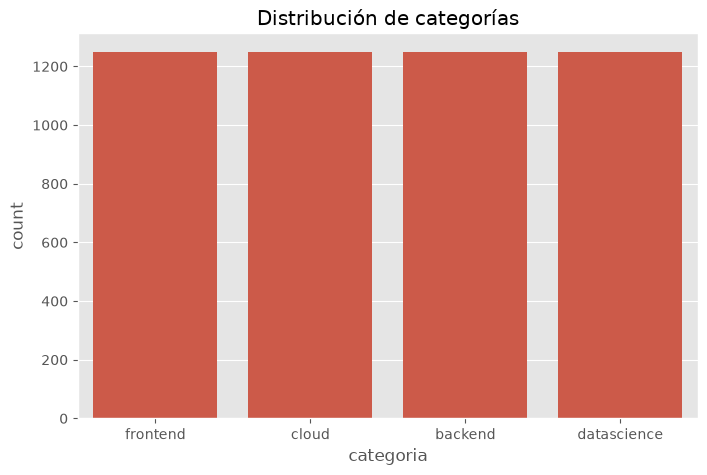

In [ ]:
# ==============================================================================
# CELDA 12
# GRAFICO DE DISTRIBUCIÓN DE CATEGORÍAS
# ==============================================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="categoria",
    order=df["categoria"].value_counts().index
)

plt.title("Distribución de categorías")

plt.show()

In [ ]:
# ==============================================================================
# CELDA 13
# LONGITUD DEL TEXTO
# ==============================================================================

df["longitud"] = df["texto"].str.len()

df["longitud"].describe()

count    5000.00000
mean      104.29560
std        25.16923
min        34.00000
25%        94.00000
50%        99.00000
75%       103.00000
max       379.00000
Name: longitud, dtype: float64

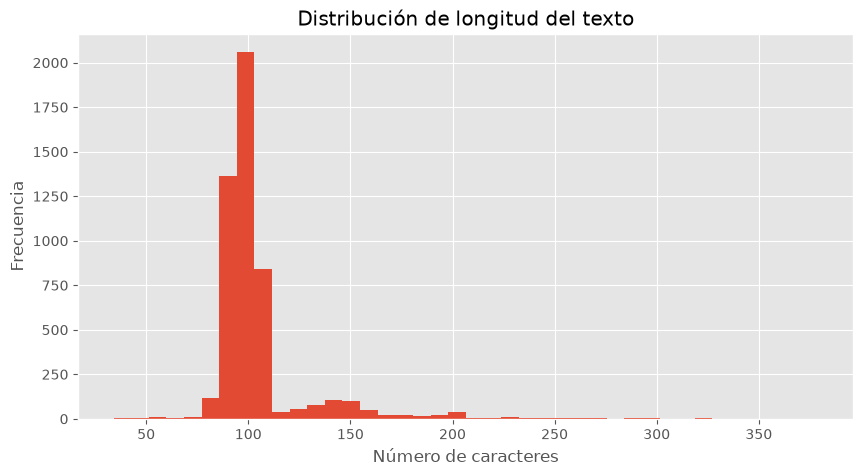

In [ ]:
# ==============================================================================
# CELDA 14
# HISTOGRAMA DE LA LONGITUD DEL TEXTO
# ==============================================================================

plt.figure(figsize=(10,5))

plt.hist(
    df["longitud"],
    bins=40
)

plt.title("Distribución de longitud del texto")

plt.xlabel("Número de caracteres")

plt.ylabel("Frecuencia")

plt.show()

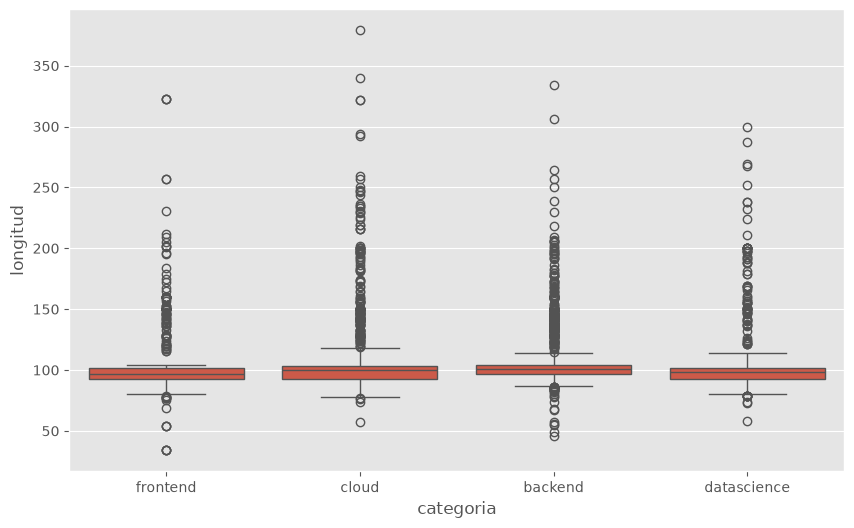

In [ ]:
# ==============================================================================
# CELDA 15
# LONGITUD DEL TEXTO POR CATEGORÍA
# ==============================================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="categoria",
    y="longitud"
)

plt.show()

In [ ]:
# ==============================================================================
# CELDA 16
# LONGITUD DEL TÍTULO
# ==============================================================================

df["titulo_longitud"] = df["titulo"].str.len()

df["titulo_longitud"].describe()

count    5000.000000
mean       64.743200
std        21.762508
min         3.000000
25%        52.000000
50%        66.000000
75%        78.000000
max       254.000000
Name: titulo_longitud, dtype: float64

In [ ]:
# ==============================================================================
# CELDA 17
# CANTIDAD DE PALABRAS POR DOCUMENTO
# ==============================================================================

df["num_palabras"] = df["texto"].apply(
    lambda x: len(str(x).split())
)

df["num_palabras"].describe()

count    5000.000000
mean       16.016200
std         4.701995
min         5.000000
25%        13.000000
50%        15.000000
75%        18.000000
max        55.000000
Name: num_palabras, dtype: float64

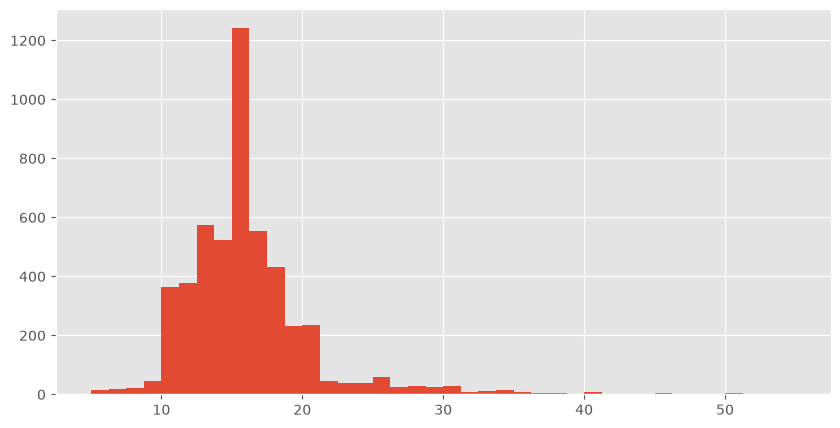

In [ ]:
# ==============================================================================
# CELDA 18
# DISTRIBUCIÓN DE LA CANTIDAD DE PALABRAS POR DOCUMENTO
# ==============================================================================

plt.figure(figsize=(10,5))

plt.hist(
    df["num_palabras"],
    bins=40
)

plt.show()

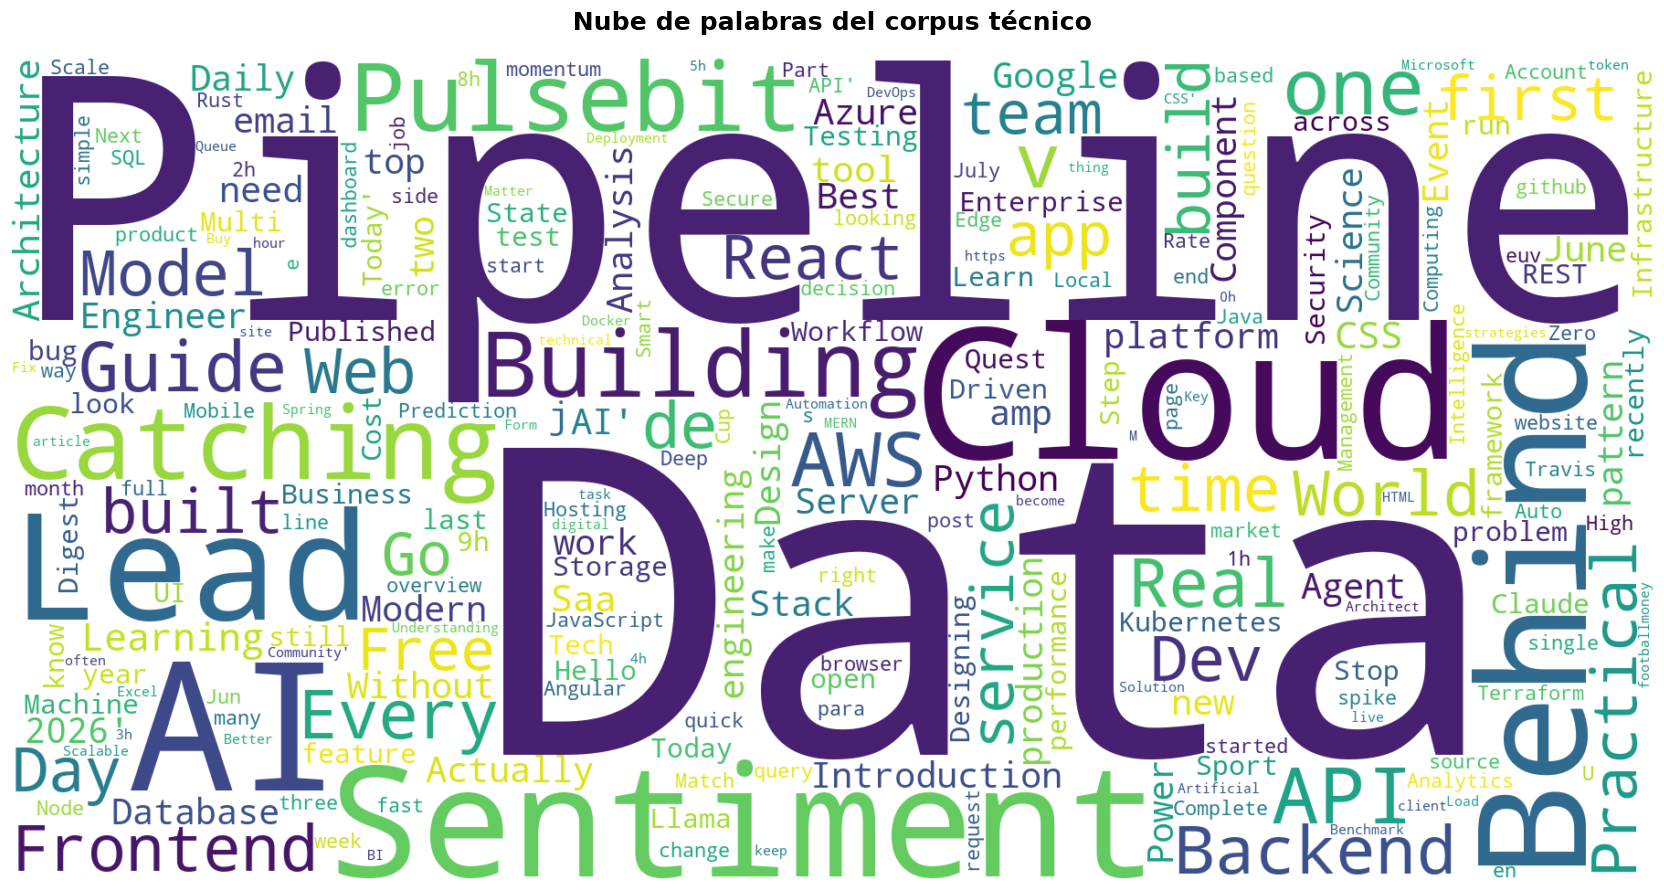

In [ ]:
# ==============================================================================
# CELDA 19
# NUBE DE PALABRAS DEL CORPUS COMPLETO
# ==============================================================================

from wordcloud import WordCloud, STOPWORDS

# ------------------------------------------------------------------------------
# Construcción del corpus
# ------------------------------------------------------------------------------

# Se combinan todas las columnas de texto para obtener una representación
# más completa del contenido del dataset.
corpus = (
    df["titulo"].fillna("") + " " +
    df["texto"].fillna("") + " " +
    df["palabras_clave"].fillna("")
)

texto_completo = " ".join(corpus)

# ------------------------------------------------------------------------------
# Stopwords adicionales del dominio técnico
# ------------------------------------------------------------------------------

custom_stopwords = {
    "using",
    "use",
    "used",
    "example",
    "examples",
    "project",
    "projects",
    "application",
    "applications",
    "software",
    "system",
    "systems",
    "user",
    "users",
    "file",
    "files",
    "code",
    "coding",
    "developer",
    "developers",
    "development",
    "technology",
    "technologies"
}

stopwords = STOPWORDS.union(custom_stopwords)

# ------------------------------------------------------------------------------
# Generación de la nube de palabras
# ------------------------------------------------------------------------------

wordcloud = WordCloud(
    width=1800,
    height=900,
    background_color="white",
    stopwords=stopwords,
    collocations=False,
    max_words=250,
    contour_width=1,
    contour_color="steelblue",
    random_state=42
).generate(texto_completo)

# ------------------------------------------------------------------------------
# Visualización
# ------------------------------------------------------------------------------

plt.figure(figsize=(18,9))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title(
    "Nube de palabras del corpus técnico",
    fontsize=18,
    weight="bold",
    pad=20
)

plt.tight_layout()

plt.show()

In [ ]:
# CELDA 20

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english"
)

X = vectorizer.fit_transform(df["texto"])

frecuencias = np.asarray(
    X.sum(axis=0)
).ravel()

palabras = vectorizer.get_feature_names_out()

top = (
    pd.DataFrame({
        "Palabra": palabras,
        "Frecuencia": frecuencias
    })
    .sort_values(
        "Frecuencia",
        ascending=False
    )
)

top.head(30)

,Palabra,Frecuencia
2021,data,494
5579,pipeline,434
1507,cloud,414
471,ai,356
6794,sentiment,352
1137,building,331
4304,leads,326
1292,catching,321
101,2026,319
5984,pulsebit,304


,Palabra,Frecuencia
65,2026,1044
250,ai,1012
1133,data,1004
3179,pipeline,907
838,cloud,885
3913,sentiment,805
2436,leads,783
721,catching,744
3414,pulsebit,705
636,building,675


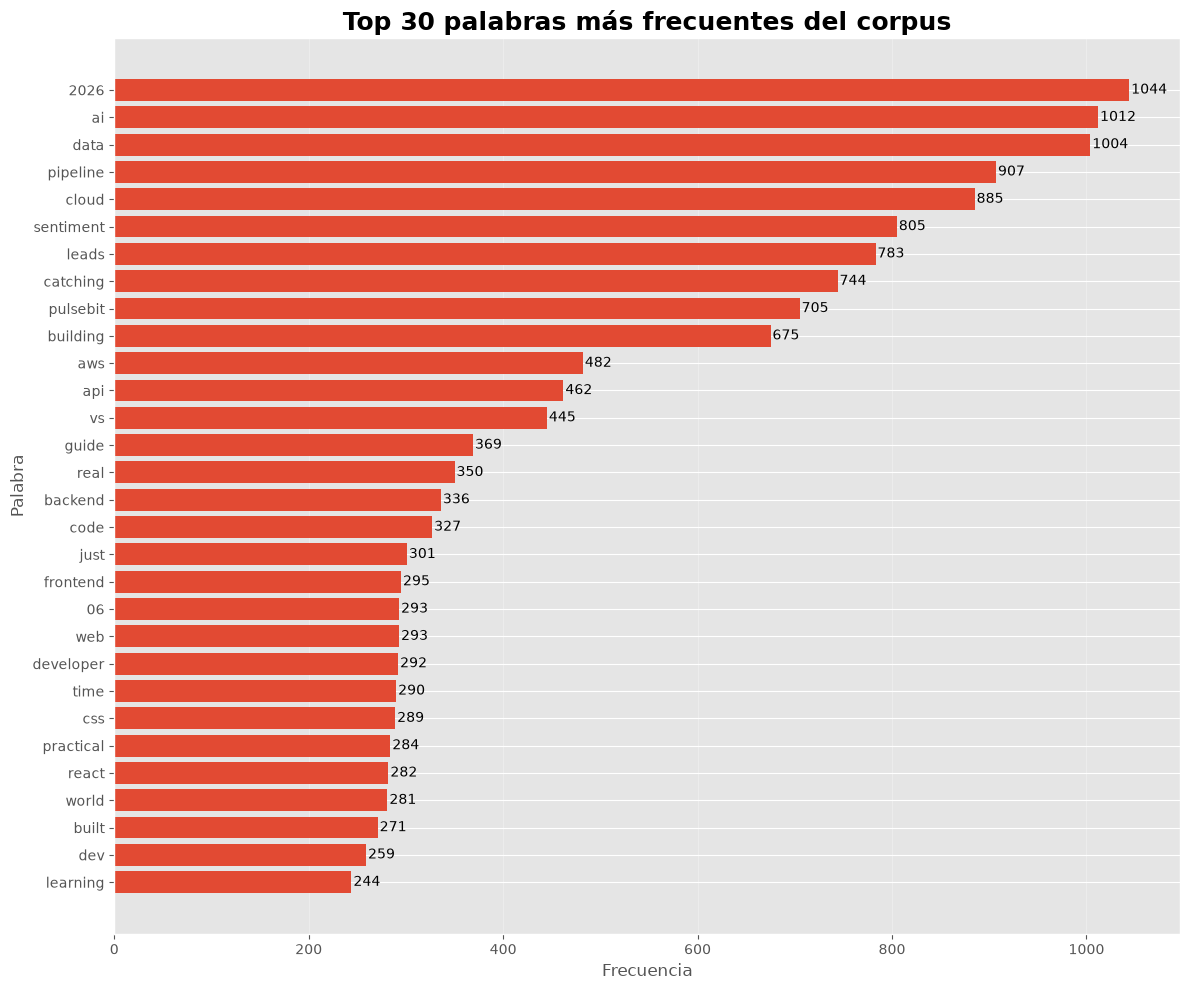

In [ ]:
# ==============================================================================
# CELDA 21
# TOP 30 PALABRAS MÁS FRECUENTES DEL CORPUS
# ==============================================================================

from sklearn.feature_extraction.text import CountVectorizer

# ------------------------------------------------------------------------------
# Construcción del corpus completo
# ------------------------------------------------------------------------------

corpus = (
    df["titulo"].fillna("") + " " +
    df["texto"].fillna("") + " " +
    df["palabras_clave"].fillna("")
)

# ------------------------------------------------------------------------------
# Vectorización
# ------------------------------------------------------------------------------

vectorizer = CountVectorizer(
    stop_words="english",
    lowercase=True,
    max_features=5000
)

X = vectorizer.fit_transform(corpus)

frecuencias = X.sum(axis=0).A1

palabras = vectorizer.get_feature_names_out()

# ------------------------------------------------------------------------------
# DataFrame con frecuencias
# ------------------------------------------------------------------------------

top_palabras = (
    pd.DataFrame({
        "Palabra": palabras,
        "Frecuencia": frecuencias
    })
    .sort_values("Frecuencia", ascending=False)
    .head(30)
)

display(top_palabras)

# ------------------------------------------------------------------------------
# Visualización
# ------------------------------------------------------------------------------

plt.figure(figsize=(12,10))

plt.barh(
    top_palabras["Palabra"][::-1],
    top_palabras["Frecuencia"][::-1]
)

# Etiquetas de frecuencia
for i, valor in enumerate(top_palabras["Frecuencia"][::-1]):
    plt.text(
        valor + 2,
        i,
        str(valor),
        va="center",
        fontsize=10
    )

plt.title(
    "Top 30 palabras más frecuentes del corpus",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Frecuencia")

plt.ylabel("Palabra")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

,Bigrama,Frecuencia
0,sentiment leads,773
1,leads pulsebit,705
2,pulsebit pipeline,376
3,2026 06,277
4,aws daily,156
5,daily digest,156
6,data science,150
7,real time,149
8,dev community,140
9,world cup,118


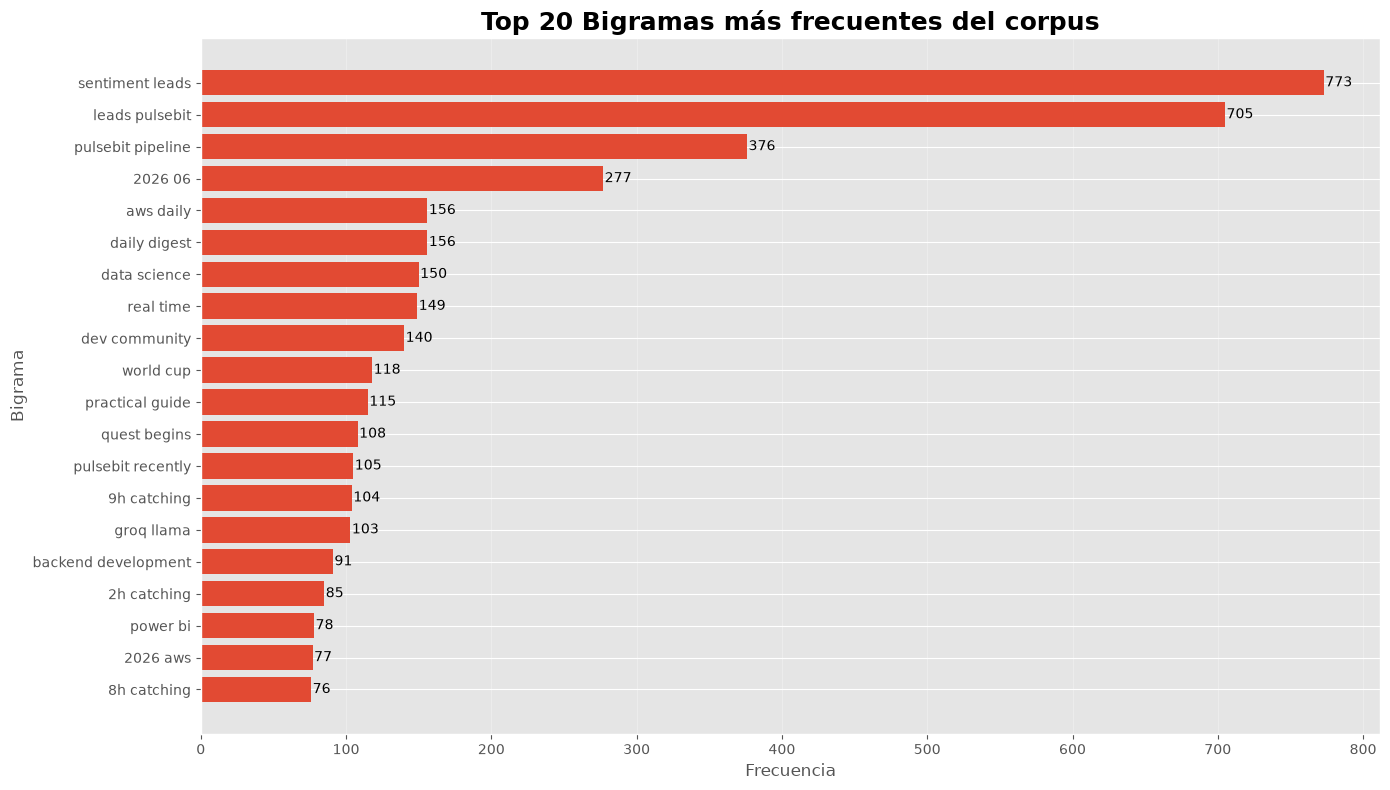

In [ ]:
# ==============================================================================
# CELDA 22
# TOP 20 BIGRAMAS MÁS FRECUENTES
# ==============================================================================

from sklearn.feature_extraction.text import CountVectorizer

# ------------------------------------------------------------------------------
# Construcción del corpus
# ------------------------------------------------------------------------------

corpus = (
    df["titulo"].fillna("") + " " +
    df["texto"].fillna("") + " " +
    df["palabras_clave"].fillna("")
)

# ------------------------------------------------------------------------------
# Vectorización utilizando Bigramas
# ------------------------------------------------------------------------------

vectorizer_bigram = CountVectorizer(
    stop_words="english",
    lowercase=True,
    ngram_range=(2,2),
    min_df=2
)

X_bigram = vectorizer_bigram.fit_transform(corpus)

# ------------------------------------------------------------------------------
# Obtención de frecuencias
# ------------------------------------------------------------------------------

frecuencias = X_bigram.sum(axis=0).A1

bigramas = vectorizer_bigram.get_feature_names_out()

df_bigramas = (
    pd.DataFrame({
        "Bigrama": bigramas,
        "Frecuencia": frecuencias
    })
    .sort_values("Frecuencia", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(df_bigramas)

# ------------------------------------------------------------------------------
# Visualización
# ------------------------------------------------------------------------------

plt.figure(figsize=(14,8))

plt.barh(
    df_bigramas["Bigrama"][::-1],
    df_bigramas["Frecuencia"][::-1]
)

# Mostrar frecuencia al final de cada barra
for i, valor in enumerate(df_bigramas["Frecuencia"][::-1]):
    plt.text(
        valor + 1,
        i,
        str(valor),
        va="center",
        fontsize=10
    )

plt.title(
    "Top 20 Bigramas más frecuentes del corpus",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Frecuencia")

plt.ylabel("Bigrama")

plt.grid(axis="x", alpha=0.30)

plt.tight_layout()

plt.show()

,Trigrama,Frecuencia
0,sentiment leads pulsebit,705
1,leads pulsebit pipeline,376
2,aws daily digest,156
3,leads pulsebit recently,105
4,web developer travis,73
5,hello dev community,70
6,2026 aws daily,70
7,daily digest june,70
8,leads pulsebit just,68
9,match prediction model,67


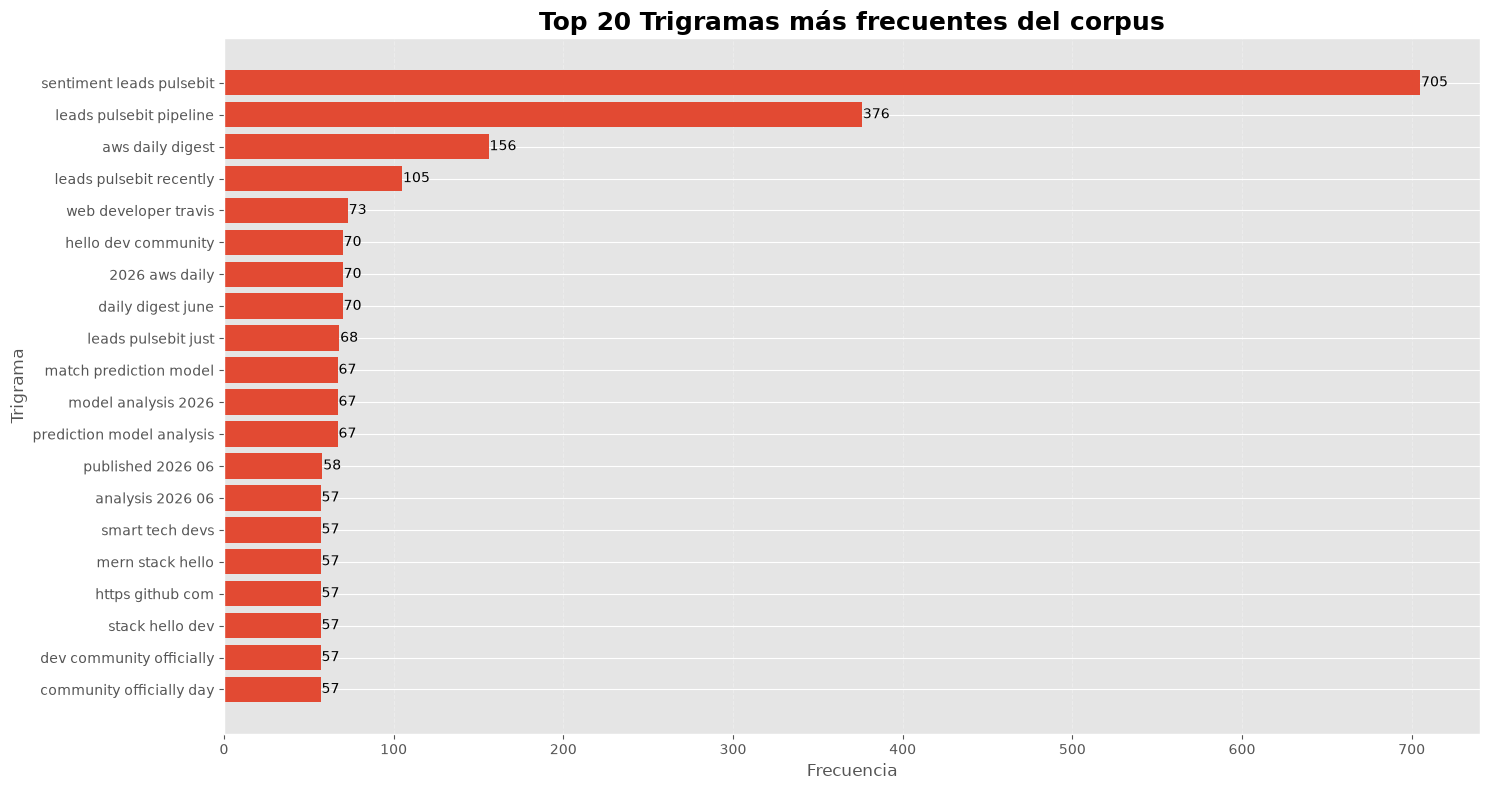

In [ ]:
# ==============================================================================
# CELDA 23
# TOP 20 TRIGRAMAS MÁS FRECUENTES DEL CORPUS
# ==============================================================================

from sklearn.feature_extraction.text import CountVectorizer

# ------------------------------------------------------------------------------
# Construcción del corpus completo
# ------------------------------------------------------------------------------

corpus = (
    df["titulo"].fillna("") + " " +
    df["texto"].fillna("") + " " +
    df["palabras_clave"].fillna("")
)

# ------------------------------------------------------------------------------
# Vectorización utilizando únicamente trigramas
# ------------------------------------------------------------------------------

vectorizer_trigram = CountVectorizer(
    stop_words="english",
    lowercase=True,
    ngram_range=(3,3),
    min_df=2
)

X_trigram = vectorizer_trigram.fit_transform(corpus)

# ------------------------------------------------------------------------------
# Obtención de frecuencias
# ------------------------------------------------------------------------------

frecuencias = X_trigram.sum(axis=0).A1

trigramas = vectorizer_trigram.get_feature_names_out()

df_trigramas = (
    pd.DataFrame({
        "Trigrama": trigramas,
        "Frecuencia": frecuencias
    })
    .sort_values("Frecuencia", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(df_trigramas)

# ------------------------------------------------------------------------------
# Visualización
# ------------------------------------------------------------------------------

plt.figure(figsize=(15,8))

plt.barh(
    df_trigramas["Trigrama"][::-1],
    df_trigramas["Frecuencia"][::-1]
)

# Etiquetas de frecuencia
for i, valor in enumerate(df_trigramas["Frecuencia"][::-1]):
    plt.text(
        valor + 0.5,
        i,
        str(valor),
        va="center",
        fontsize=10
    )

plt.title(
    "Top 20 Trigramas más frecuentes del corpus",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Frecuencia")

plt.ylabel("Trigrama")

plt.grid(axis="x", linestyle="--", alpha=0.30)

plt.tight_layout()

plt.show()

,Promedio,Mediana,Desv_Estandar,Minimo,Maximo
categoria,,,,,
backend,17.19,16.0,4.68,5,49
cloud,16.62,16.0,5.17,6,55
datascience,15.30,14.0,4.20,9,51
frontend,14.97,15.0,4.35,5,53


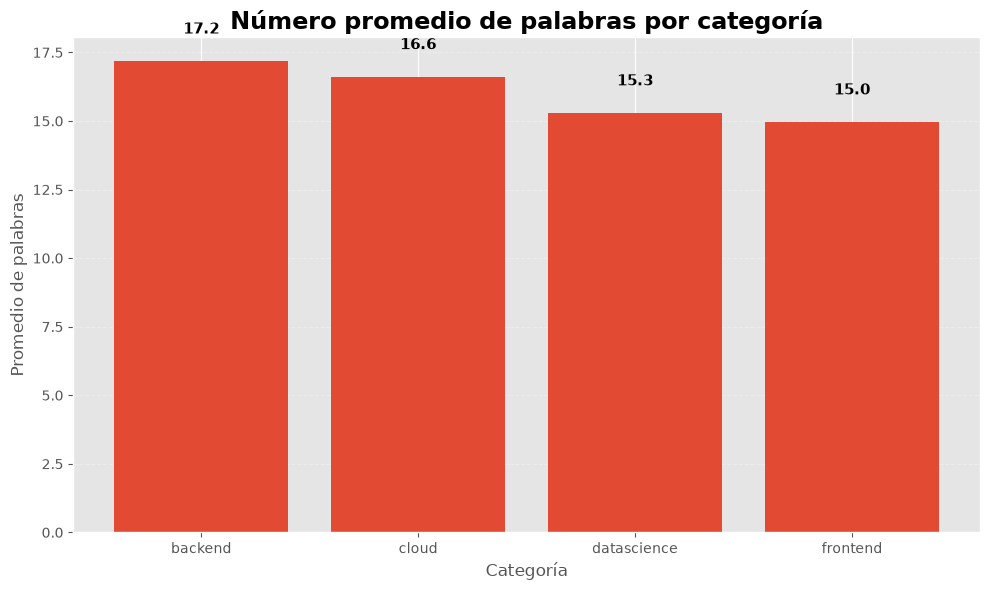

In [ ]:
# ==============================================================================
# CELDA 24
# LONGITUD DE LOS DOCUMENTOS POR CATEGORÍA
# ==============================================================================

# ------------------------------------------------------------------------------
# Cálculo del número de palabras por documento
# ------------------------------------------------------------------------------

df["num_palabras"] = (
    df["texto"]
    .fillna("")
    .astype(str)
    .apply(lambda x: len(x.split()))
)

# ------------------------------------------------------------------------------
# Estadísticas descriptivas por categoría
# ------------------------------------------------------------------------------

estadisticas_categoria = (
    df.groupby("categoria")["num_palabras"]
      .agg(
          Promedio="mean",
          Mediana="median",
          Desv_Estandar="std",
          Minimo="min",
          Maximo="max"
      )
      .round(2)
      .sort_values("Promedio", ascending=False)
)

display(estadisticas_categoria)

# ------------------------------------------------------------------------------
# Visualización
# ------------------------------------------------------------------------------

plt.figure(figsize=(10,6))

bars = plt.bar(
    estadisticas_categoria.index,
    estadisticas_categoria["Promedio"]
)

# Mostrar el promedio encima de cada barra
for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura + 1,
        f"{altura:.1f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Número promedio de palabras por categoría",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Categoría")

plt.ylabel("Promedio de palabras")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ==============================================================================
# CELDA 25
# ANÁLISIS DE LA COLUMNA PALABRAS_CLAVE
# ==============================================================================

# ------------------------------------------------------------------------------
# Verificación inicial
# ------------------------------------------------------------------------------

print("="*70)
print("ANÁLISIS DE LA COLUMNA 'palabras_clave'")
print("="*70)

print(f"\nValores nulos: {df['palabras_clave'].isnull().sum()}")

print(f"Valores vacíos: {(df['palabras_clave'].fillna('').str.strip() == '').sum()}")

print("\nPrimeros registros:\n")

display(df["palabras_clave"].head())

ANÁLISIS DE LA COLUMNA 'palabras_clave'

Valores nulos: 0
Valores vacíos: 0

Primeros registros:



0                                                                        ['GeekNews', '주간']
1    ['Workbench VS Code', "AI Agent Benchmarks            Today's", 'GCP', 'Apps Gateway']
2                                                                                        []
3                                                              ['500,000-row', 'this week']
4                                                                                        []
Name: palabras_clave, dtype: str

In [ ]:
# CELDA 26
# ------------------------------------------------------------------------------
# Cantidad de palabras clave por documento
# ------------------------------------------------------------------------------

df["num_keywords"] = (
    df["palabras_clave"]
    .fillna("")
    .apply(
        lambda x: len(
            [k.strip() for k in str(x).split(",") if k.strip()]
        )
    )
)

display(df["num_keywords"].describe())

count    5000.000000
mean        1.563800
std         1.026129
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         9.000000
Name: num_keywords, dtype: float64

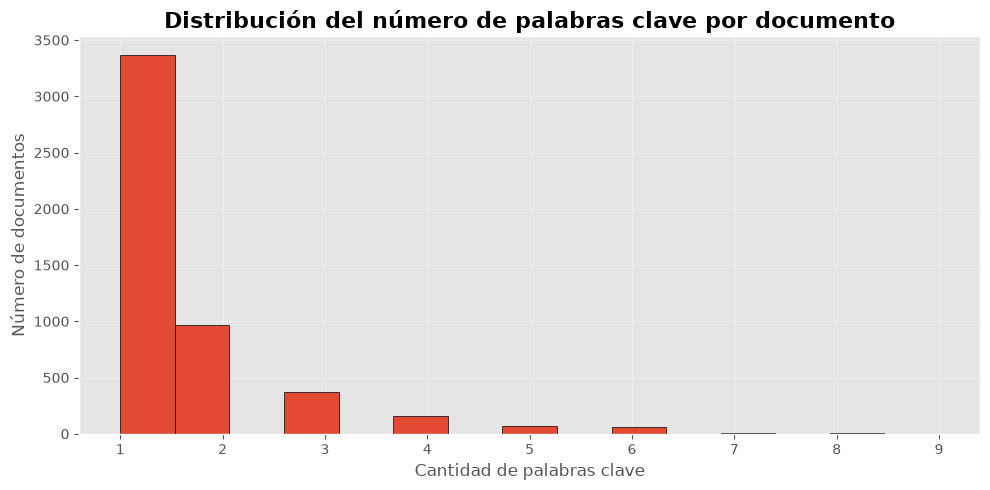

In [ ]:
# CELDA 27
# ------------------------------------------------------------------------------
# Distribución del número de keywords
# ------------------------------------------------------------------------------

plt.figure(figsize=(10,5))

plt.hist(
    df["num_keywords"],
    bins=15,
    edgecolor="black"
)

plt.title(
    "Distribución del número de palabras clave por documento",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Cantidad de palabras clave")

plt.ylabel("Número de documentos")

plt.grid(alpha=0.30)

plt.tight_layout()

plt.show()

In [ ]:
# CELDA 28
# ------------------------------------------------------------------------------
# Top 30 palabras clave más frecuentes
# ------------------------------------------------------------------------------

from collections import Counter

contador = Counter()

for fila in df["palabras_clave"].fillna(""):

    palabras = [
        palabra.strip().lower()
        for palabra in str(fila).split(",")
        if palabra.strip()
    ]

    contador.update(palabras)

top_keywords = (
    pd.DataFrame(
        contador.items(),
        columns=["Keyword","Frecuencia"]
    )
    .sort_values(
        "Frecuencia",
        ascending=False
    )
    .head(30)
)

display(top_keywords)

,Keyword,Frecuencia
6,[],1560
78,['ai'],69
269,'llama 3.3',52
270,'free &',51
154,['today'],44
91,['2026',44
290,'today'],42
268,['groq',42
153,['24h'],42
150,['ai',36


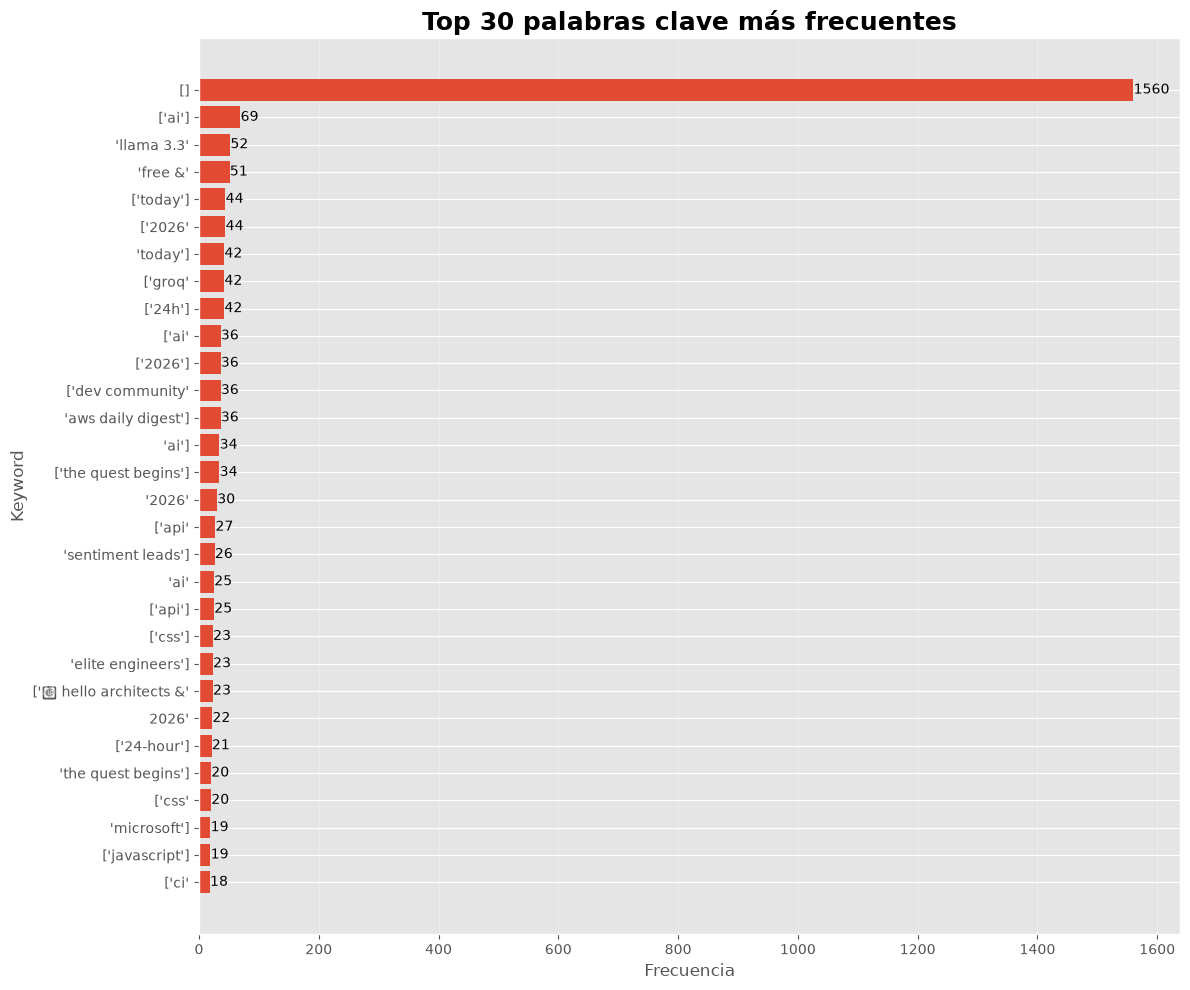

In [ ]:
# CELDA 29
# ------------------------------------------------------------------------------
# Visualización Top 30 Keywords
# ------------------------------------------------------------------------------

plt.figure(figsize=(12,10))

plt.barh(
    top_keywords["Keyword"][::-1],
    top_keywords["Frecuencia"][::-1]
)

for i, valor in enumerate(top_keywords["Frecuencia"][::-1]):

    plt.text(
        valor + 0.5,
        i,
        str(valor),
        va="center",
        fontsize=10
    )

plt.title(
    "Top 30 palabras clave más frecuentes",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Frecuencia")

plt.ylabel("Keyword")

plt.grid(axis="x", alpha=0.30)

plt.tight_layout()

plt.show()

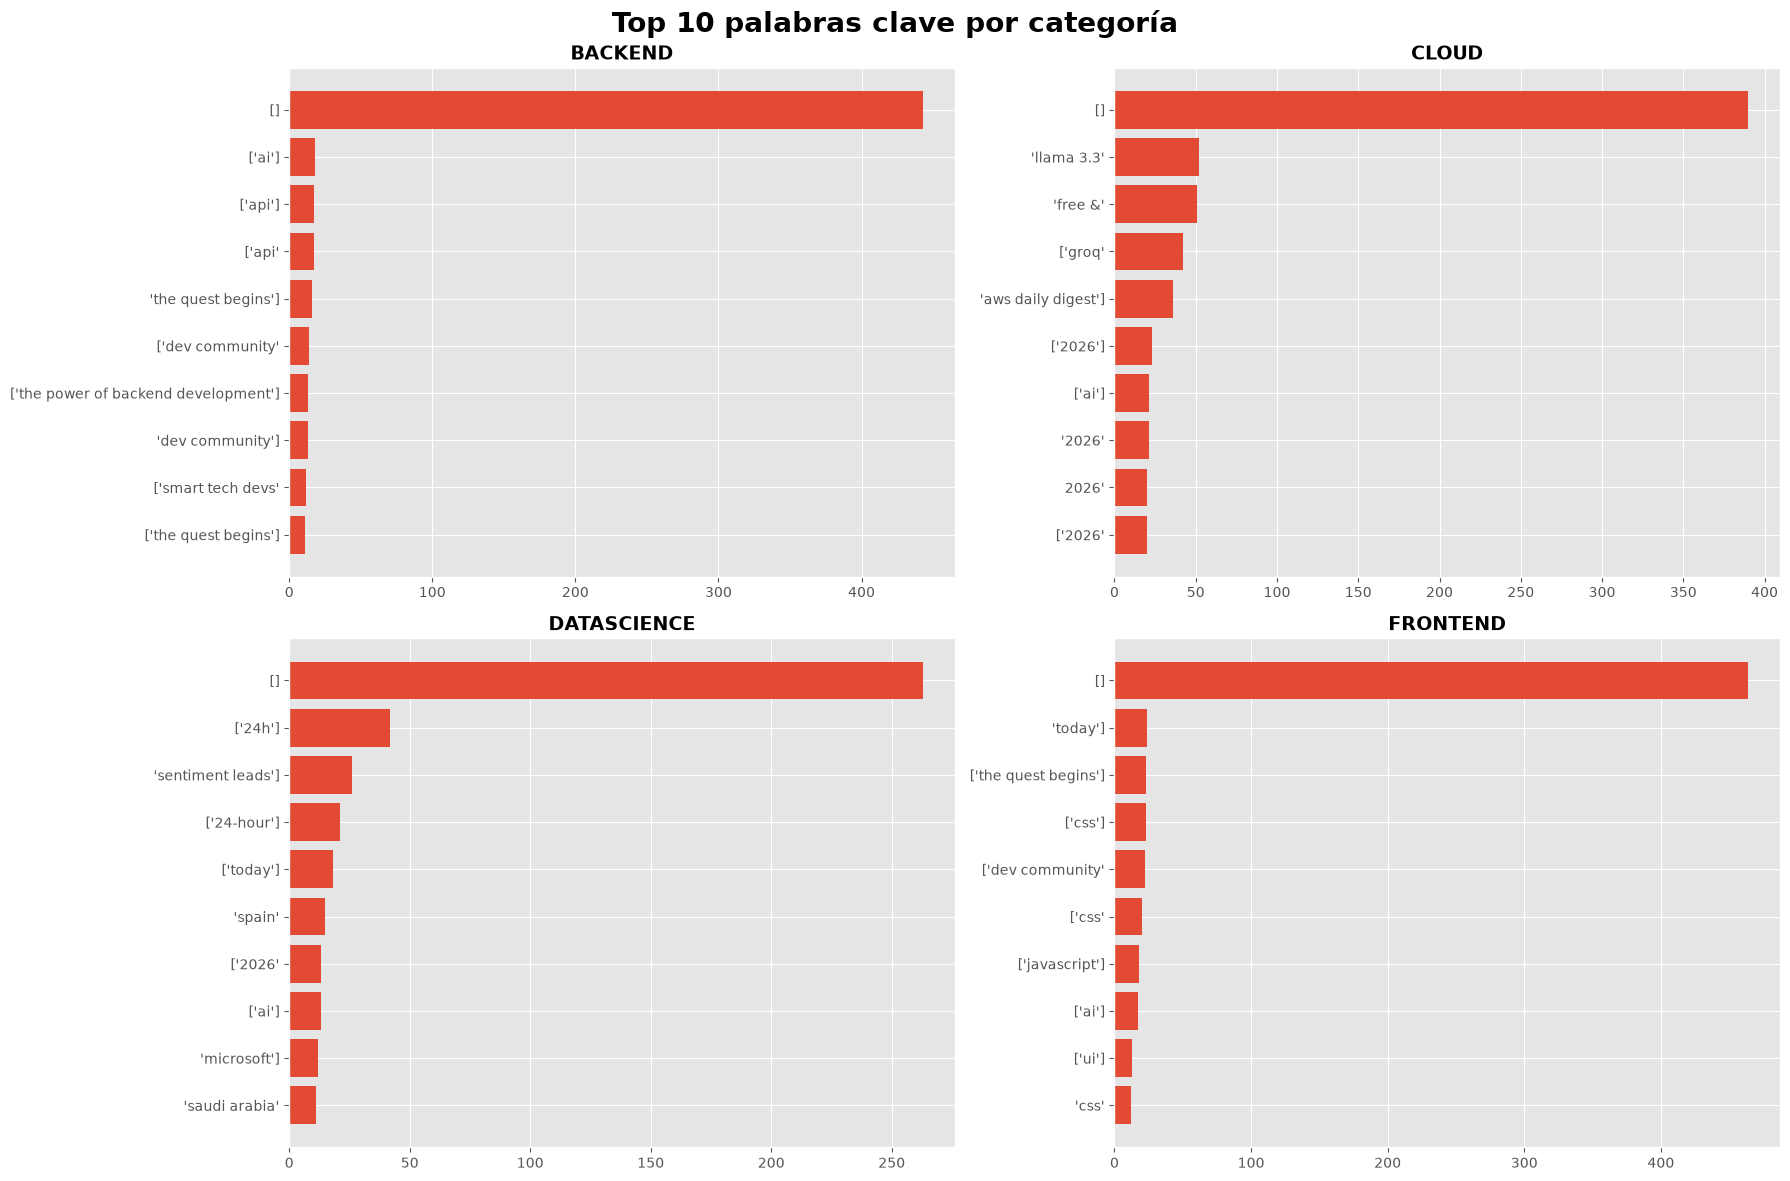

In [ ]:
# CELDA 30
# ==============================================================================
# TOP 10 PALABRAS CLAVE POR CATEGORÍA
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

categorias = sorted(df["categoria"].unique())

for ax, categoria in zip(axes.flatten(), categorias):

    contador = Counter()

    subset = df[df["categoria"] == categoria]

    for fila in subset["palabras_clave"].fillna(""):

        palabras = [
            p.strip().lower()
            for p in str(fila).split(",")
            if p.strip()
        ]

        contador.update(palabras)

    top = (
        pd.DataFrame(
            contador.items(),
            columns=["Keyword","Frecuencia"]
        )
        .sort_values(
            "Frecuencia",
            ascending=False
        )
        .head(10)
    )

    ax.barh(
        top["Keyword"][::-1],
        top["Frecuencia"][::-1]
    )

    ax.set_title(
        categoria.upper(),
        fontsize=14,
        fontweight="bold"
    )

plt.suptitle(
    "Top 10 palabras clave por categoría",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [ ]:
# CELDA 31

df["palabras_clave"].iloc[0]

"['GeekNews', '주간']"

In [ ]:
# CELDA 32

import ast
from collections import Counter

contador = Counter()

for fila in df["palabras_clave"].fillna("[]"):

    try:

        keywords = ast.literal_eval(fila)

        keywords = [
            str(k).strip().lower()
            for k in keywords
            if str(k).strip()
        ]

        contador.update(keywords)

    except Exception:
        continue

top_keywords = (
    pd.DataFrame(
        contador.items(),
        columns=["Keyword","Frecuencia"]
    )
    .sort_values("Frecuencia", ascending=False)
    .head(30)
)

display(top_keywords)

,Keyword,Frecuencia
75,ai,164
80,2026,121
57,today,109
21,api,75
40,css,63
259,dev community,61
17,the quest begins,54
242,groq,52
243,llama 3.3,52
245,aws daily digest,52


In [ ]:
# CELDA 33

import ast

contador = Counter()

for fila in subset["palabras_clave"].fillna("[]"):

    try:

        keywords = ast.literal_eval(fila)

        keywords = [
            str(k).strip().lower()
            for k in keywords
            if str(k).strip()
        ]

        contador.update(keywords)

    except Exception:
        continue

Matriz de correlación:



,longitud,titulo_longitud,num_palabras,num_keywords
longitud,1.000000,0.013606,0.861051,0.173635
titulo_longitud,0.013606,1.000000,-0.023405,-0.029203
num_palabras,0.861051,-0.023405,1.000000,0.205740
num_keywords,0.173635,-0.029203,0.205740,1.000000


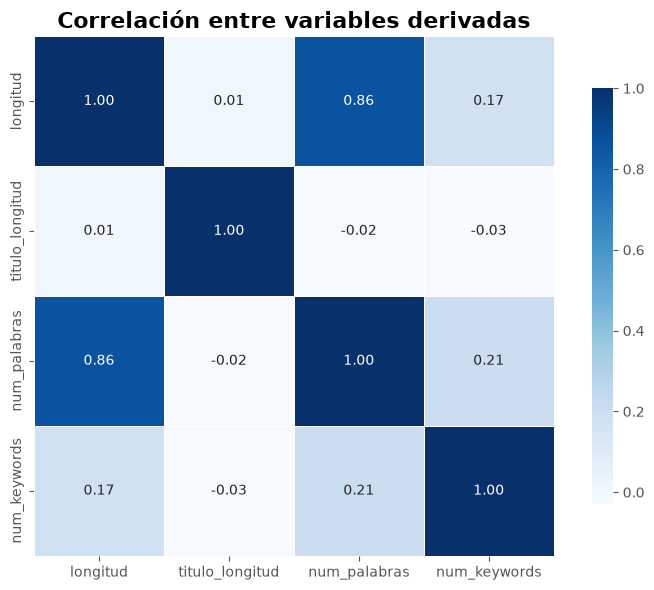

In [58]:
# ==============================================================================
# CELDA 34
# MATRIZ DE CORRELACIÓN ENTRE VARIABLES DERIVADAS
# ==============================================================================

# ------------------------------------------------------------------------------
# Selección de variables numéricas
# ------------------------------------------------------------------------------

variables_numericas = [
    "longitud",
    "titulo_longitud",
    "num_palabras",
    "num_keywords"
]

correlacion = (
    df[variables_numericas]
    .corr(method="pearson")
)

print("Matriz de correlación:\n")

display(correlacion)

# ------------------------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------------------------

plt.figure(figsize=(8,6))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8}
)

plt.title(
    "Correlación entre variables derivadas",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [59]:
# ------------------------------------------------------------------------------
# CELDA 35
# Correlaciones ordenadas
# ------------------------------------------------------------------------------

corr_pairs = (
    correlacion
    .unstack()
    .reset_index()
)

corr_pairs.columns = [
    "Variable_1",
    "Variable_2",
    "Correlacion"
]

corr_pairs = corr_pairs[
    corr_pairs["Variable_1"] < corr_pairs["Variable_2"]
]

corr_pairs = corr_pairs.sort_values(
    "Correlacion",
    ascending=False
)

display(corr_pairs)

,Variable_1,Variable_2,Correlacion
2,longitud,num_palabras,0.861051
14,num_keywords,num_palabras,0.205740
3,longitud,num_keywords,0.173635
1,longitud,titulo_longitud,0.013606
9,num_palabras,titulo_longitud,-0.023405
13,num_keywords,titulo_longitud,-0.029203


In [60]:
# ==============================================================================
# CELDA 36
# RESUMEN EJECUTIVO DEL ANÁLISIS EXPLORATORIO (EDA)
# ==============================================================================

print("=" * 80)
print("RESUMEN EJECUTIVO DEL ANÁLISIS EXPLORATORIO")
print("=" * 80)

print("""
El Análisis Exploratorio de Datos (EDA) permitió comprender la estructura,
calidad y características principales del conjunto de datos utilizado para el
desarrollo del sistema de clasificación de contenido técnico TechMind v2.0.

PRINCIPALES HALLAZGOS

1. Calidad del conjunto de datos
   • El dataset presenta una estructura consistente para las variables
     principales.
   • No se identificaron problemas significativos de valores faltantes en las
     columnas críticas para el modelado.

2. Distribución de clases
   • Las cuatro categorías (Backend, Frontend, Cloud y Data Science)
     presentan una distribución balanceada.
   • Esto reduce el riesgo de sesgo durante el entrenamiento y permite utilizar
     métricas como Accuracy, Precision, Recall y F1-Score con mayor confianza.

3. Características del texto
   • La longitud de los documentos muestra una variabilidad natural entre
     registros.
   • No se observaron diferencias extremas entre categorías que justifiquen
     filtrados por tamaño.

4. Vocabulario del corpus
   • El análisis de palabras, bigramas y trigramas permitió identificar
     terminología técnica representativa de cada dominio.
   • Esto confirma la existencia de patrones lingüísticos diferenciados entre
     categorías.

5. Palabras clave
   • La columna 'palabras_clave' contiene información potencialmente valiosa,
     aunque también presenta ruido generado durante el proceso de extracción.
   • Será necesario aplicar un proceso de limpieza y normalización antes de
     incorporarla al modelo predictivo.

6. Variables derivadas
   • La longitud del texto y el número de palabras presentan una alta
     correlación, lo cual era esperado.
   • El número de palabras clave aporta información complementaria, por lo que
     será considerado como una característica adicional tras su depuración.

CONCLUSIÓN

El conjunto de datos posee las condiciones necesarias para construir un modelo
de clasificación supervisada de alto rendimiento.

Los resultados del EDA respaldan la utilización de técnicas de Procesamiento
de Lenguaje Natural (NLP) basadas en TF-IDF con n-gramas y modelos lineales,
además de evidenciar la necesidad de una etapa de preprocesamiento orientada a
la limpieza y normalización del texto.

En el siguiente notebook se desarrollará el pipeline completo de
preprocesamiento, incluyendo limpieza textual, normalización, eliminación de
ruido y preparación de las características que serán utilizadas durante el
entrenamiento del modelo.
""")

RESUMEN EJECUTIVO DEL ANÁLISIS EXPLORATORIO

El Análisis Exploratorio de Datos (EDA) permitió comprender la estructura,
calidad y características principales del conjunto de datos utilizado para el
desarrollo del sistema de clasificación de contenido técnico TechMind v2.0.

PRINCIPALES HALLAZGOS

1. Calidad del conjunto de datos
   • El dataset presenta una estructura consistente para las variables
     principales.
   • No se identificaron problemas significativos de valores faltantes en las
     columnas críticas para el modelado.

2. Distribución de clases
   • Las cuatro categorías (Backend, Frontend, Cloud y Data Science)
     presentan una distribución balanceada.
   • Esto reduce el riesgo de sesgo durante el entrenamiento y permite utilizar
     métricas como Accuracy, Precision, Recall y F1-Score con mayor confianza.

3. Características del texto
   • La longitud de los documentos muestra una variabilidad natural entre
     registros.
   • No se observaron diferencias extremas